# Final Simulation Notebook

## 0) Imports, globals

In [8]:
from pathlib import Path
import json, time, os, sys
from datetime import datetime

# Add the src directory to the system path
project_root = os.path.abspath('..')
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import ttest_rel

# Custom modules
from data_generation.source_data import SimulationDataGeneration
from data_generation.shifted_data import ShiftedSimulationDataGeneration
from utils.seed import set_seed

from simulation.monte_carlo_simulation import MonteCarloSimulation
from models.pytorch_model import PyTorchModel as MLP
from models.xgb_model_hetero import XGBoostModel
from models.ft_mdn_transformer import FTTransformerModel

## 1) YAML loader + paths

In [11]:
import yaml

def load_yaml_config(path):
    """Loads YAML; allows python tags (e.g., !!python/object/apply) used in your configs."""
    path = Path(path)
    with open(path, "r") as f:
        return yaml.load(f, Loader=yaml.UnsafeLoader)  # trust your own repo files

# Point to your real files (as you wrote)
source_config_file        = "../configs/simulation/source_data_config_categories.yaml"
shift_param_ranges_file   = "../configs/simulation/monte_carlo_config.yaml"

source_config       = load_yaml_config(source_config_file)
shift_param_ranges  = load_yaml_config(shift_param_ranges_file)

print("Loaded:", source_config_file, "|", shift_param_ranges_file)

Loaded: ../configs/simulation/source_data_config_categories.yaml | ../configs/simulation/monte_carlo_config.yaml


## 2) Output dirs + plotting style (Times New Roman, PDFs)

In [19]:
mpl.rcParams['font.family']  = 'Times New Roman'
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

STAMP   = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_ROOT = Path(f"../outputs/sim_runs_{STAMP}")
FIG_DIR  = OUT_ROOT / "figures"
RES_DIR  = OUT_ROOT / "results"
DATA_DIR = OUT_ROOT / "data"
for d in (FIG_DIR, RES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

def savefig_pdf(path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight")
    print("📄 saved:", path)


## 3) Design: shift types, heterogeneity, sizes, scenarios

In [24]:
SHIFT_TYPES = ["covariate", "conditional", "label"]
HETERO_FEATURE_MODES = ["equal", "source_subset", "target_subset"]
DROP_FRACTION = 0.33             # set >0.0 to drop fraction of shiftable features on one side
TARGET_SIZES = [100, 500, 1000]
SCENARIOS    = [
    ['target_only', 'transfer'], 
    ['target_only', 'transfer'], 
    ['target_only', 'transfer'], 
    ['target_only', 'transfer']
] # one list per model (below)
EVAL_ALL_ON_TARGET = True
NUM_SIMULATIONS    = 5

print("Grid ready.")


Grid ready.


## 4) Models — exact best params + ablation (MDN vs Regression)

In [27]:
#MLP
MLP_PARAMS = dict( 
    hidden_layers=[128, 64],
    output_size=1,
    learning_rate=0.00005,
    epochs=40,
    batch_size=64
)


# XGBoost
XGB_PARAMS = dict(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0,
)

# FT-Transformer — your best params
FT_MDN_BEST = dict(
    d_token=32, n_heads=4, n_blocks=2, ff_factor=4.0, dropout=0.0,
    learning_rate=1e-4, weight_decay=0.0,
    mdn_n_components=2, mdn_temperature=2.5, mdn_hidden_size=24,
    batch_size=64, use_mdn=True, use_interaction=True,
    use_scheduler=False, epochs=80,
    deterministic=True, benchmark=False, early_stopping=True,
)

# Ablation: Regression head (same backbone/training; use_mdn=False)
FT_REG = dict(FT_MDN_BEST, **{"use_mdn": False})

MODEL_CLASSES = [MLP, XGBoostModel, FTTransformerModel, FTTransformerModel]
MODEL_NAMES   = ["MLP", "XGB", "FT-MDN", "FT-Reg"]
MODEL_PARAMS  = [
    MLP_PARAMS,
    dict(xgb_params=XGB_PARAMS, epochs=XGB_PARAMS['n_estimators']),  # <- epochs present
    FT_MDN_BEST,
    FT_REG,
]

print("Models:", MODEL_NAMES)


Models: ['MLP', 'XGB', 'FT-MDN', 'FT-Reg']


## 5) Sweep: shift_type × hetero × target_n

In [12]:
INDEX_CSV = RES_DIR / "index.csv"
rows = []
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

for shift_type in SHIFT_TYPES:
    for hetero in HETERO_FEATURE_MODES:
        for tgt_n in TARGET_SIZES:
            sim = MonteCarloSimulation(
                source_config=source_config,
                shift_param_ranges=shift_param_ranges,   # single config as you requested
                shift_type=shift_type,
                num_simulations=NUM_SIMULATIONS,
                model_class=MODEL_CLASSES,
                model_names=MODEL_NAMES,
                model_params=MODEL_PARAMS,
                scenarios=SCENARIOS,
                hetero_feature_mode=hetero,
                drop_fraction=DROP_FRACTION,
                store_datasets=False,
                verbose=1,
                output_folder=str(OUT_ROOT),
            )
            t0 = time.time()
            sim.run(eval_all_on_target=EVAL_ALL_ON_TARGET, target_data_size=tgt_n)
            elapsed = time.time() - t0

            # save explicit copies (raw is already written by class too)
            stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            raw_path = RES_DIR / f"raw_{stamp}_{shift_type}_{hetero}_n{tgt_n}.csv"
            sim.results_df.to_csv(raw_path, index=False)

            summary = sim.summarize_results()
            sum_path = RES_DIR / f"summary_{stamp}_{shift_type}_{hetero}_n{tgt_n}.csv"
            summary.to_csv(sum_path, index=False)

            rows.append(dict(
                run_id=RUN_ID, shift_type=shift_type, hetero=hetero,
                target_n=tgt_n,
                raw=str(raw_path.relative_to(OUT_ROOT)),
                summary=str(sum_path.relative_to(OUT_ROOT)),
                seconds=round(elapsed, 2)
            ))
            print(f"✓ {shift_type}/{hetero}/n{tgt_n} ({elapsed:.1f}s)")
            print("=========================================================================================")

idx = pd.DataFrame(rows)
idx.to_csv(INDEX_CSV, index=False)
display(idx.tail(10))
print("📑 index:", INDEX_CSV)


[run_simulation] Requested 100 for target train => generating 1100 total target samples (so leftover ≥ 1000 for test).
X_source cols: Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Feature_7', 'Borrower_Industry', 'Feature_Interaction'],
      dtype='object')
X_shifted cols: Index(['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5',
       'Feature_6', 'Feature_7', 'Borrower_Industry', 'Feature_Interaction'],
      dtype='object')
0: Source - Train: (6000, 9), (6000,) | Test: (2000, 9), (2000,) || Target - Train: (100, 9), (100,) | Test: (1000, 9), (1000,)
[XGB] Train Done.
[XGB] Train Done.
[XGB] finetune start: +50 trees, extras=0, missing=0
[XGB] finetune done ✓ continued boosting to 150 trees (last RMSE=0.0034)


Training epochs (FT-MDN-Transformer):   0%|          | 0/40 [00:00<?, ?it/s]

✅ Early stop at epoch 16.


Training epochs (FT-MDN-Transformer):   0%|          | 0/80 [00:00<?, ?it/s]

✅ Early stop at epoch 23.


...

✅ Early stop at epoch 24.


Training epochs (FT-MDN-Transformer):   0%|          | 0/40 [00:00<?, ?it/s]

✅ Early stop at epoch 31.
[run] Raw simulation results saved to 'sim_runs_20250817_130825/results/raw_simulation_results_20250817_1829.csv'
[summarize_results] Summarized results saved to sim_runs_20250817_130825/results/summarized_results_sim5_20250817_1829.csv
✓ label/target_subset/n1000 (845.2s)


,run_id,shift_type,hetero,target_n,raw,summary,seconds
17,20250817_130825,conditional,target_subset,1000,results/raw_20250817_161258_conditional_target...,results/summary_20250817_161258_conditional_ta...,557.09
18,20250817_130825,label,equal,100,results/raw_20250817_162949_label_equal_n100.csv,results/summary_20250817_162949_label_equal_n1...,1010.57
19,20250817_130825,label,equal,500,results/raw_20250817_165108_label_equal_n500.csv,results/summary_20250817_165108_label_equal_n5...,1278.83
20,20250817_130825,label,equal,1000,results/raw_20250817_171504_label_equal_n1000.csv,results/summary_20250817_171504_label_equal_n1...,1435.87
21,20250817_130825,label,source_subset,100,results/raw_20250817_172425_label_source_subse...,results/summary_20250817_172425_label_source_s...,561.33
22,20250817_130825,label,source_subset,500,results/raw_20250817_173629_label_source_subse...,results/summary_20250817_173629_label_source_s...,723.77
23,20250817_130825,label,source_subset,1000,results/raw_20250817_174751_label_source_subse...,results/summary_20250817_174751_label_source_s...,682.52
24,20250817_130825,label,target_subset,100,results/raw_20250817_180202_label_target_subse...,results/summary_20250817_180202_label_target_s...,850.73
25,20250817_130825,label,target_subset,500,results/raw_20250817_181512_label_target_subse...,results/summary_20250817_181512_label_target_s...,789.58
26,20250817_130825,label,target_subset,1000,results/raw_20250817_182917_label_target_subse...,results/summary_20250817_182917_label_target_s...,845.17


📑 index: sim_runs_20250817_130825/results/index.csv


## 6) Aggregate + Overleaf tables

In [20]:
def load_index_and_summaries(index_csv=INDEX_CSV):
    idx = pd.read_csv(index_csv)
    merged = []
    for _, r in idx.iterrows():
        meta = r[['shift_type','hetero','target_n']].to_dict()
        df = pd.read_csv(OUT_ROOT / r['summary'])
        for _, x in df.iterrows():
            merged.append({**meta, **x.to_dict()})
    return pd.DataFrame(merged)

full = load_index_and_summaries()

# If summarize_results used 'model_index' as label, normalize to 'model_name'
if 'model_name' not in full.columns and 'model_index' in full.columns:
    full.rename(columns={'model_index':'model_name'}, inplace=True)

group_cols = ['shift_type','hetero','target_n','model_name']
metrics = [
    'r2_source_only_mean','r2_target_only_mean','r2_transfer_learning_mean',
    'mse_source_only_mean','mse_target_only_mean','mse_transfer_learning_mean',
    'mae_source_only_mean','mae_target_only_mean','mae_transfer_learning_mean'
]
agg = (full.groupby(group_cols)[metrics]
           .agg(['mean','std'])
           .reset_index())
agg.columns = ['_'.join(c).strip('_') for c in agg.columns.values]

agg_csv = RES_DIR / "agg_run_averaged.csv"
agg_tex = RES_DIR / "agg_run_averaged.tex"
agg.to_csv(agg_csv, index=False)
with open(agg_tex, "w") as f:
    f.write(agg.to_latex(index=False, float_format="%.3f"))
print("📊 saved:", agg_csv, "|", agg_tex)
display(agg.head(10))


📊 saved: sim_runs_20250817_130825/results/agg_run_averaged.csv | sim_runs_20250817_130825/results/agg_run_averaged.tex


/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/1614607463.py:32: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(agg.to_latex(index=False, float_format="%.3f"))


,shift_type,hetero,target_n,model_name,r2_source_only_mean_mean,r2_source_only_mean_std,r2_target_only_mean_mean,r2_target_only_mean_std,r2_transfer_learning_mean_mean,r2_transfer_learning_mean_std,...,mse_target_only_mean_mean,mse_target_only_mean_std,mse_transfer_learning_mean_mean,mse_transfer_learning_mean_std,mae_source_only_mean_mean,mae_source_only_mean_std,mae_target_only_mean_mean,mae_target_only_mean_std,mae_transfer_learning_mean_mean,mae_transfer_learning_mean_std
0,conditional,equal,100,FT-MDN,NaN,NaN,0.200290,NaN,0.721822,NaN,...,0.077064,NaN,0.026832,NaN,NaN,NaN,0.243677,NaN,0.120796,NaN
1,conditional,equal,100,FT-Reg,NaN,NaN,0.666237,NaN,0.800360,NaN,...,0.032189,NaN,0.019257,NaN,NaN,NaN,0.143642,NaN,0.105741,NaN
2,conditional,equal,100,MLP,NaN,NaN,-1.341405,NaN,0.447049,NaN,...,0.225790,NaN,0.053304,NaN,NaN,NaN,0.373463,NaN,0.195460,NaN
3,conditional,equal,100,XGB,NaN,NaN,0.796286,NaN,0.775309,NaN,...,0.019655,NaN,0.021670,NaN,NaN,NaN,0.097555,NaN,0.110424,NaN
4,conditional,equal,500,FT-MDN,NaN,NaN,0.801686,NaN,0.849076,NaN,...,0.019551,NaN,0.014883,NaN,NaN,NaN,0.111466,NaN,0.084247,NaN
5,conditional,equal,500,FT-Reg,NaN,NaN,0.823253,NaN,0.851235,NaN,...,0.017422,NaN,0.014664,NaN,NaN,NaN,0.099461,NaN,0.090752,NaN
6,conditional,equal,500,MLP,NaN,NaN,0.419910,NaN,0.562818,NaN,...,0.057212,NaN,0.043131,NaN,NaN,NaN,0.205980,NaN,0.176728,NaN
7,conditional,equal,500,XGB,NaN,NaN,0.846797,NaN,0.823628,NaN,...,0.015100,NaN,0.017383,NaN,NaN,NaN,0.084184,NaN,0.095871,NaN
8,conditional,equal,1000,FT-MDN,NaN,NaN,0.851510,NaN,0.864993,NaN,...,0.014638,NaN,0.013311,NaN,NaN,NaN,0.085366,NaN,0.076127,NaN
9,conditional,equal,1000,FT-Reg,NaN,NaN,0.836066,NaN,0.855526,NaN,...,0.016168,NaN,0.014235,NaN,NaN,NaN,0.092930,NaN,0.084313,NaN


## B) LOAD RAWS & R² vs. KL INTENSITY (R² vs. shift_scores)

In [ ]:
def load_all_raw(index_csv=INDEX_CSV):
    idx = pd.read_csv(index_csv)
    rows = []
    for _, r in idx.iterrows():
        meta = r[['shift_type','hetero','target_n']].to_dict()
        df = pd.read_csv(OUT_ROOT / r['raw'])
        for _, x in df.iterrows():
            rows.append({**meta, **x.to_dict()})
    df = pd.DataFrame(rows)
    if 'model_name' not in df.columns and 'model_index' in df.columns:
        df.rename(columns={'model_index':'model_name'}, inplace=True)
    return df

raw_all = load_all_raw()

In [193]:
def plot_transfer_vs_combined_score(
    df,
    target_n=None,                 # keep for backwards-compatibility; if None -> all target sizes
    figsize=(6.5, 5),              # wider than tall
    save_path=None,
    scatter_size=20,
    scatter_alpha=0.2,
    font_family="Times New Roman",
    x_range=None,                  # (xmin, xmax) or None
    average_over_target_n=True     # <- NEW: average across target sizes at identical x per model
):
    """
    Single-plot: R² (Transfer Learning) vs Combined KL (all shifts pooled).
    - Scatter points per model (faint, same color as line)
    - Per-model linear regression lines
    - y-axis clipped to [0, 1]
    - Optionally averages across target sizes for identical (model, combined_shift_score)
    """

    # Typography for paper style
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
    })

    need = ["combined_shift_score", "r2_transfer_learning", "model_name"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = (df
            .dropna(subset=["combined_shift_score", "r2_transfer_learning", "model_name"])
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["combined_shift_score", "r2_transfer_learning"])
            .copy())

    # Optional filter (if you *really* want one target_n)
    if target_n is not None:
        data = data[data["target_n"] == target_n].copy()
        if data.empty:
            raise ValueError(f"No data left for target_n == {target_n}")

    # Average across target sizes when multiple rows share same (model, combined score)
    if average_over_target_n:
        data = (data.groupby(["model_name", "combined_shift_score"], as_index=False)
                    ["r2_transfer_learning"].mean())

    # Colors per model
    model_names = sorted(data["model_name"].unique())
    cmap = plt.get_cmap("tab10")
    colors = {m: cmap(i % 10) for i, m in enumerate(model_names)}

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # X range
    if isinstance(x_range, tuple):
        xmin, xmax = x_range
    else:
        xmin, xmax = data["combined_shift_score"].min(), data["combined_shift_score"].max()
        span = xmax - xmin if np.isfinite(xmax - xmin) else 1.0
        pad = 0.02 * span if span > 0 else 0.1
        xmin, xmax = xmin - pad, xmax + pad
    xs = np.linspace(xmin, xmax, 200)

    # Scatter + regression per model
    for name, sub in data.groupby("model_name"):
        x = sub["combined_shift_score"].values
        y = sub["r2_transfer_learning"].values
        if len(x) < 2:
            continue

        ax.scatter(x, y, s=scatter_size, alpha=scatter_alpha,
                   color=colors[name], edgecolors="none")

        m, b = np.polyfit(x, y, 1)
        ax.plot(xs, m * xs + b, linewidth=2, color=colors[name], label=name)

    ax.set_title("R² (Transfer Learning) vs Combined KL")
    ax.set_xlabel("Combined KL")
    ax.set_ylabel("R² (Transfer Learning)")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.0, 1.0)   # crop to [0, 1]
    ax.grid(True, alpha=0.3)

    # Legend at bottom (lines only)
    proxies = [Line2D([0], [0], color=colors[m], lw=2, label=m) for m in model_names]
    ncol = min(len(model_names), 4)
    fig.legend(proxies, [p.get_label() for p in proxies],
               loc="lower center", bbox_to_anchor=(0.5, -0),
               ncol=ncol, frameon=False)

    fig.tight_layout(rect=[0, 0.08, 1, 1])

    if save_path is not None:
        try:
            savefig_pdf(save_path)
        except Exception:
            fig.savefig(save_path, bbox_inches="tight")

    return fig, ax


📄 saved: sim_runs_20250817_130825/figures/r2_transfer_vs_combinedKL_allTargets.pdf


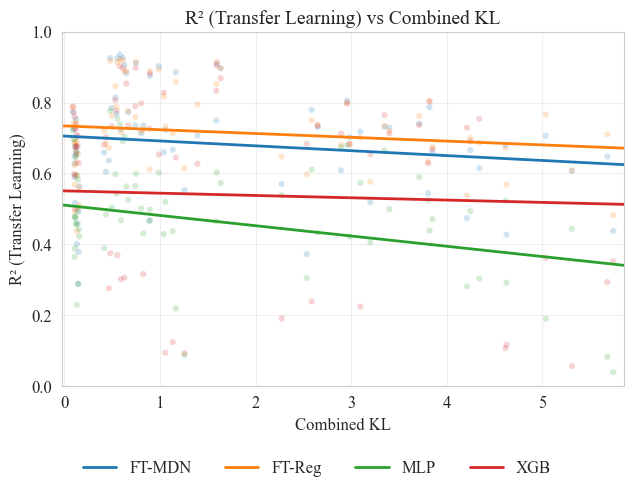

In [195]:
fig, ax = plot_transfer_vs_combined_score(
    raw_all,
    figsize=(6.5, 5),
    average_over_target_n=True,   # default True
    save_path=FIG_DIR / "r2_transfer_vs_combinedKL_allTargets.pdf"
)


In [145]:
def plot_transfer_vs_shift_by_type(
    df,
    target_n=None,
    panel_size=5,
    y_max=1.0,
    save_path=None,
    scatter_size=20,
    scatter_alpha=0.2,
    font_family="Times New Roman"
):
    """
    Plot R² (Transfer Learning) vs shift intensity with three side-by-side square panels.

    - Covariate shift:   x = feature_shift_score
    - Concept shift:     x = feature_shift_score
    - Label shift:       x = label_shift_score
    """

    # Font for scientific paper style
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
    })

    need = [
        "shift_type", "model_name", "r2_transfer_learning",
        "feature_shift_score", "label_shift_score", "target_n"
    ]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter
    data = (df
            .dropna(subset=["r2_transfer_learning", "model_name", "shift_type"])
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["r2_transfer_learning"])
            .copy())

    if target_n is not None:
        data = data[data["target_n"] == target_n].copy()
        if data.empty:
            raise ValueError(f"No data left for target_n == {target_n}")

    # Shifts and x-vars
    shift_specs = [
        ("covariate",   "feature_shift_score", "Covariate shift"),
        ("conditional", "feature_shift_score", "Concept shift"),
        ("label",       "label_shift_score",   "Label shift"),
    ]
    present = [(s, x, l) for (s, x, l) in shift_specs if s in data["shift_type"].unique()]
    if not present:
        raise ValueError("No required shift types present in the data.")

    # Consistent colors per model
    model_names = sorted(data["model_name"].unique())
    cmap = plt.get_cmap("tab10")
    colors = {m: cmap(i % 10) for i, m in enumerate(model_names)}

    # Layout
    fig_w = panel_size * len(present)
    fig_h = panel_size
    fig, axes = plt.subplots(1, len(present), figsize=(fig_w, fig_h), sharey=True)
    if len(present) == 1:
        axes = np.array([axes])

    ymin, ymax = 0.0, y_max

    for ax, (shift_name, xcol, title) in zip(axes, present):
        sub = data[data["shift_type"] == shift_name].dropna(subset=[xcol]).copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        xmin, xmax = sub[xcol].min(), sub[xcol].max()
        xspan = xmax - xmin if np.isfinite(xmax - xmin) else 1.0
        pad = 0.02 * xspan if xspan > 0 else 0.1
        xs = np.linspace(xmin - pad, xmax + pad, 100)

        for name, mdf in sub.groupby("model_name"):
            x = mdf[xcol].values
            y = mdf["r2_transfer_learning"].values
            if len(x) < 2:
                continue

            ax.scatter(
                x, y,
                s=scatter_size,
                alpha=scatter_alpha,
                color=colors[name],
                edgecolors="none"
            )

            m, b = np.polyfit(x, y, 1)
            ax.plot(xs, m * xs + b, linewidth=2, color=colors[name], label=name)

        ax.set_title(title, pad=10)
        ax.set_xlabel(xcol.replace("_", " ").capitalize())
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(1)

    axes[0].set_ylabel("R² (Transfer Learning)")

    # Legend at bottom
    proxies = [Line2D([0], [0], color=colors[m], lw=1.8, label=m) for m in model_names]
    ncol = min(len(model_names), 4)
    fig.legend(
        proxies,
        [p.get_label() for p in proxies],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        frameon=False
    )

    fig.tight_layout(rect=[0, 0.07, 1, 1])

    if save_path is not None:
        try:
            savefig_pdf(save_path)  # if helper available
        except Exception:
            fig.savefig(save_path, bbox_inches="tight")

    return fig, axes


📄 saved: sim_runs_20250817_130825/figures/r2_transfer_by_shift_target100.pdf


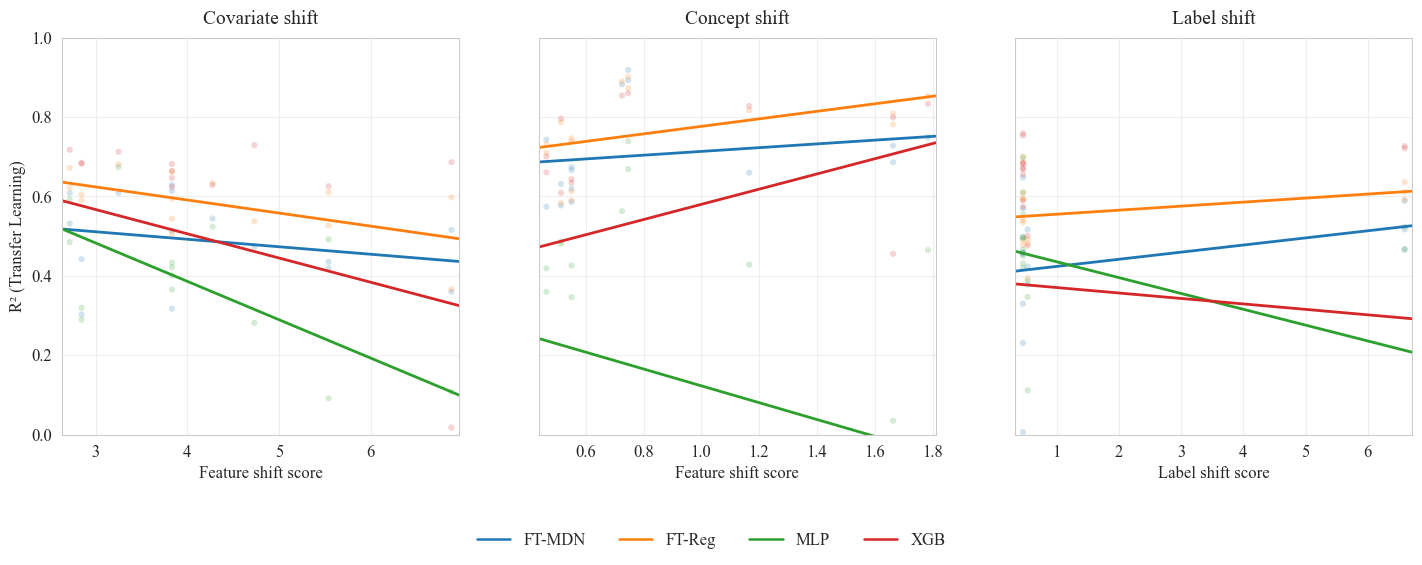

In [147]:
fig, axes = plot_transfer_vs_shift_by_type(
    raw_all,
    target_n=100,
    panel_size=5,
    save_path=FIG_DIR / "r2_transfer_by_shift_target100.pdf"
)


📄 saved: sim_runs_20250817_130825/figures/r2_transfer_by_shift_target500.pdf


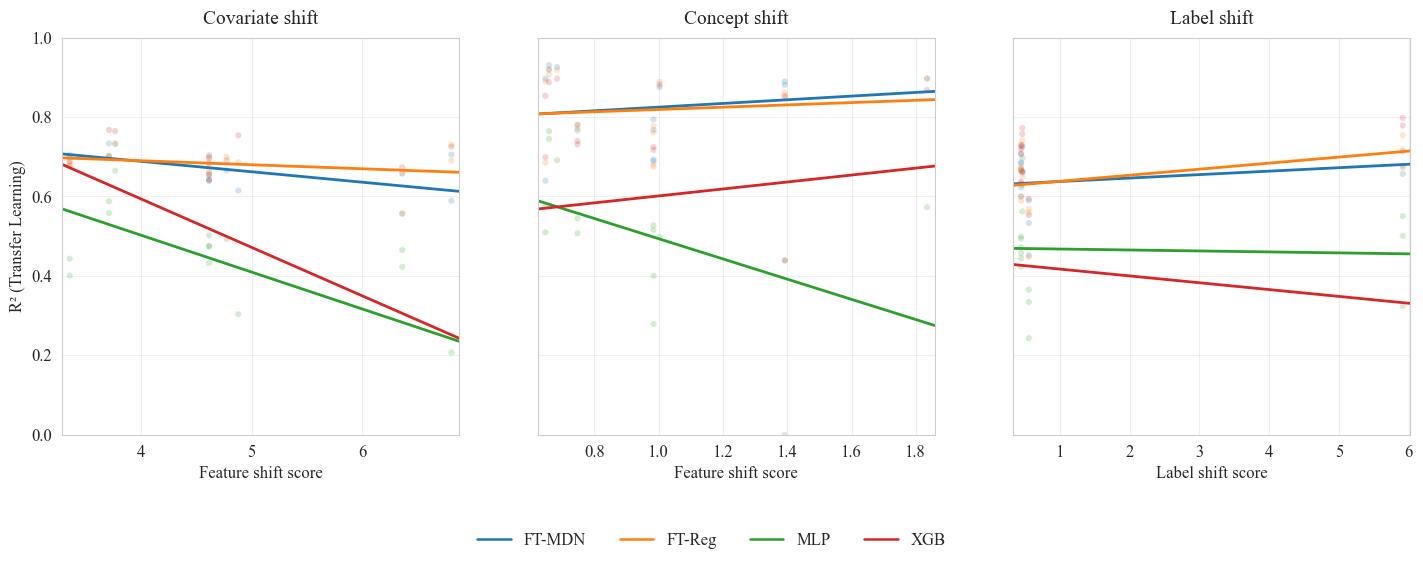

In [149]:
fig, axes = plot_transfer_vs_shift_by_type(
    raw_all,
    target_n=500,
    panel_size=5,
    save_path=FIG_DIR / "r2_transfer_by_shift_target500.pdf"
)


📄 saved: sim_runs_20250817_130825/figures/r2_transfer_by_shift_target1000.pdf


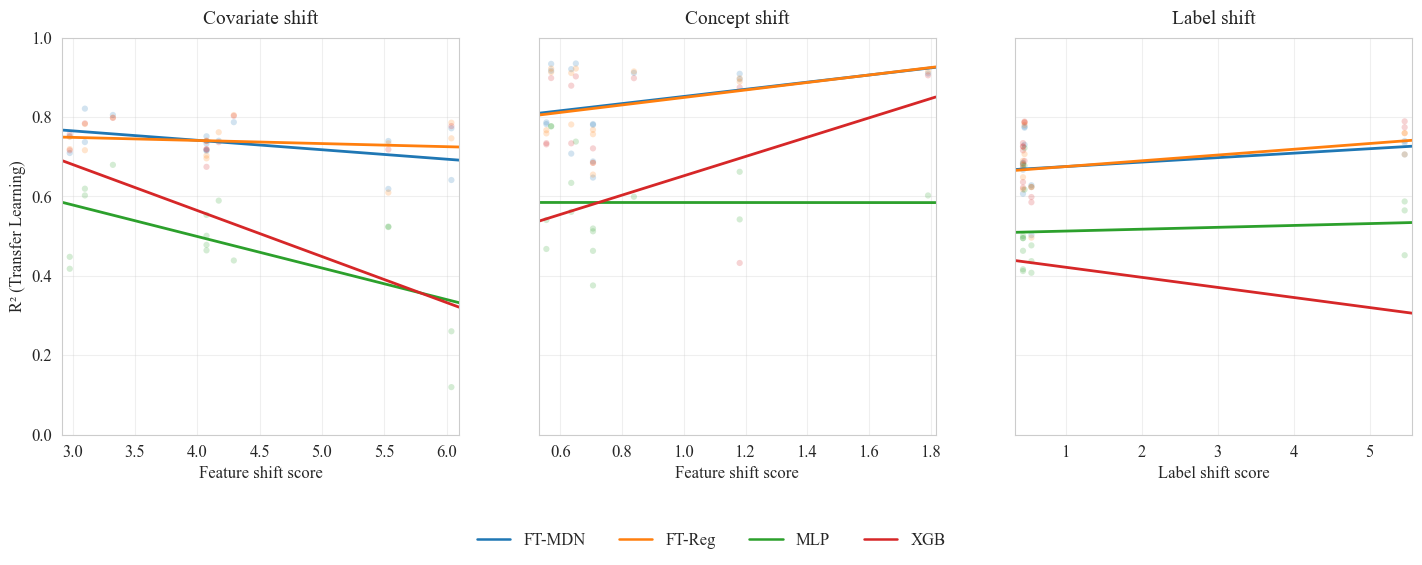

In [151]:
fig, axes = plot_transfer_vs_shift_by_type(
    raw_all,
    target_n=1000,
    panel_size=5,
    save_path=FIG_DIR / "r2_transfer_by_shift_target1000.pdf"
)


### R² vs feature heterogeneity

def load_all_raw(index_df: pd.DataFrame, base: Path) -> pd.DataFrame:
    dfs = []
    for _, r in index_df.iterrows():
        raw_path = base / r['raw']
        if not raw_path.exists(): 
            print(f"skip missing: {raw_path}")
            continue
        df = pd.read_csv(raw_path)
        if df.empty: 
            continue
        # add metadata so you can facet/filter later
        df['run_id']     = r['run_id']
        df['shift_type'] = r['shift_type']
        df['hetero']     = r['hetero']
        df['target_n']   = r['target_n']
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

all_raw = load_all_raw(idx, OUT_ROOT)
print(all_raw.shape)
all_raw.head()


In [285]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

def plot_hetero_transfer_highlight(
    df,
    target_n=None,
    panel_size=5,
    save_path=None,
    font_family="Times New Roman",
    hetero_order=('equal','source_subset','target_subset'),
    models_order=None,                 # e.g., ['FT-MDN','FT-Reg','XGB','MLP']
    y_range=(0, 1),
    transfer_style='violin',           # <- default to violin
    single_color="#5b89b0",
    box_alpha=0.35,                    # also used for violin face alpha
    marker_size=50,
    line_alpha=0.6,
    legend_ncol=3,
    show_delta=False,
    delta_fmt="{:+.2f}",
    summary='median'                   # 'median' (default) or 'mean' for both dots
):
    """
    Highlight transfer performance under feature heterogeneity.

    For each heterogeneity scenario (panel) and each model:
      - Transfer distribution (violin/box) in a single color
      - Filled dot = Transfer summary (median by default)
      - Hollow dot = Target-Only summary (same statistic)
      - Thin connector: Target-Only → Transfer (ΔR²)

    Titles (mathtext, no unicode):
      Equal ($F_s = F_t$), Source $\subset$ Target ($F_s \subset F_t$), Target $\subset$ Source ($F_t \subset F_s$)
    """

    # --- checks ---
    needed = {'hetero','model_name','r2_target_only','r2_transfer_learning'}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.copy()
    if target_n is not None:
        if 'target_n' not in data.columns:
            raise ValueError("target_n filter requested but 'target_n' column not found.")
        data = data[data['target_n'] == target_n].copy()
        if data.empty:
            raise ValueError(f"No data left after filtering target_n == {target_n}")

    # Typography / mathtext (avoid unicode glyph issues)
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
        "mathtext.fontset": "stix",   # crisp math glyphs
        "mathtext.default": "regular"
    })

    # Orderings
    hetero_order = list(hetero_order)
    if models_order is None:
        models = sorted(data['model_name'].unique())
    else:
        models = [m for m in models_order if m in data['model_name'].unique()]

    # Figure
    fig_w, fig_h = panel_size * len(hetero_order), panel_size
    fig, axes = plt.subplots(1, len(hetero_order), figsize=(fig_w, fig_h), sharey=True)
    if len(hetero_order) == 1:
        axes = [axes]

    ymin, ymax = (0, 1) if y_range is None else y_range

    # Choose summary function
    if summary == 'median':
        agg_fn = np.nanmedian
        summary_label = 'median'
    elif summary == 'mean':
        agg_fn = np.nanmean
        summary_label = 'mean'
    else:
        raise ValueError("summary must be 'median' or 'mean'")

    # Titles (mathtext for subset symbol)
    title_map = {
        'equal': r'Equal ($F_s = F_t$)',
        'source_subset': r'Source < Target ($F_s \subset F_t$)',
        'target_subset': r'Target < Source ($F_t \subset F_s$)',
    }

    # Per-panel plotting
    for ax, h in zip(axes, hetero_order):
        xpos = np.arange(len(models))
        tgt_vals_list, tr_vals_list = [], []

        for m in models:
            tv = data.loc[
                (data['hetero'] == h) & (data['model_name'] == m), 'r2_target_only'
            ].dropna().to_numpy()
            tr = data.loc[
                (data['hetero'] == h) & (data['model_name'] == m), 'r2_transfer_learning'
            ].dropna().to_numpy()
            tgt_vals_list.append(tv)
            tr_vals_list.append(tr)

        # --- Transfer distribution (robust to empty groups) ---
        nonempty_idx = [i for i, arr in enumerate(tr_vals_list) if len(arr) > 0]
        if transfer_style == 'violin' and nonempty_idx:
            vp = ax.violinplot(
                [tr_vals_list[i] for i in nonempty_idx],
                positions=[xpos[i] for i in nonempty_idx],
                widths=0.8,
                showmedians=False,
                showextrema=False
            )
            for b in vp['bodies']:
                b.set_facecolor(single_color)
                b.set_edgecolor(single_color)
                b.set_alpha(box_alpha)
        elif transfer_style == 'box' and nonempty_idx:
            bp = ax.boxplot(
                [tr_vals_list[i] for i in nonempty_idx],
                positions=[xpos[i] for i in nonempty_idx],
                widths=0.55,
                showfliers=False, patch_artist=True
            )
            for box in bp['boxes']:
                box.set(facecolor=single_color, alpha=box_alpha,
                        edgecolor=single_color, linewidth=1.2)
            for k in ('whiskers','caps','medians'):
                for artist in bp[k]:
                    artist.set(color=single_color, linewidth=1)
        # if all groups empty, we just skip the distribution layer

        # Summaries (same stat for both dots)
        tgt_summ = [np.nan if len(v)==0 else float(agg_fn(v)) for v in tgt_vals_list]
        tr_summ  = [np.nan if len(v)==0 else float(agg_fn(v)) for v in tr_vals_list]

        # Connectors & markers (single color)
        for i in range(len(models)):
            yt, ytr = tgt_summ[i], tr_summ[i]
            if not (np.isnan(yt) or np.isnan(ytr)):
                ax.plot([xpos[i], xpos[i]], [yt, ytr],
                        color=single_color, alpha=line_alpha, linewidth=1)
                if show_delta:
                    ax.text(xpos[i] + 0.05, ytr + 0.015*(ymax - ymin),
                            delta_fmt.format(ytr - yt),
                            color=single_color, fontsize=10, ha='left', va='bottom')

        # Target-Only (hollow point)
        for i in range(len(models)):
            yt = tgt_summ[i]
            if np.isnan(yt): continue
            ax.plot(xpos[i], yt, marker='o', ms=np.sqrt(marker_size),
                    mfc='white', mec=single_color, mew=1.2, linestyle='None')

        # Transfer summary (filled point)
        for i in range(len(models)):
            ytr = tr_summ[i]
            if np.isnan(ytr): continue
            ax.plot(xpos[i], ytr, marker='o', ms=np.sqrt(marker_size),
                    mfc=single_color, mec=single_color, linestyle='None')

        # Axes styling
        ax.set_title(title_map.get(h, str(h)), pad=8)
        ax.set_xticks(xpos, models)
        ax.set_xlabel('Model')
        ax.set_ylim(ymin, ymax)
        ax.grid(axis='y', alpha=0.3)
        for spine in ax.spines.values():
            spine.set_visible(True)

    axes[0].set_ylabel('R²')

    # Style-only legend (no model names)
    style_handles = [
        mpatches.Patch(facecolor=single_color, edgecolor=single_color, alpha=box_alpha,
                       label=f"Transfer"),
        Line2D([0],[0], marker='o', color=single_color, mfc=single_color, mec=single_color,
               linestyle='None', label=f'Transfer ({summary_label})'),
        Line2D([0],[0], marker='o', color=single_color, mfc='white', mec=single_color,
               linestyle='None', label=f'Target Only ({summary_label})'),
    ]
    fig.legend(style_handles, [h.get_label() for h in style_handles],
               loc='lower center', bbox_to_anchor=(0.5, 0.03),
               ncol=legend_ncol, frameon=False)

    fig.tight_layout(rect=[0, 0.10, 1, 1])
    plt.subplots_adjust(wspace=0.25)

    if save_path is not None:
        try:
            savefig_pdf(save_path)
        except Exception:
            fig.savefig(save_path, bbox_inches='tight')

    return fig, axes


📄 saved: sim_runs_20250817_130825/figures/hetero_transfer_violin_highlight.pdf


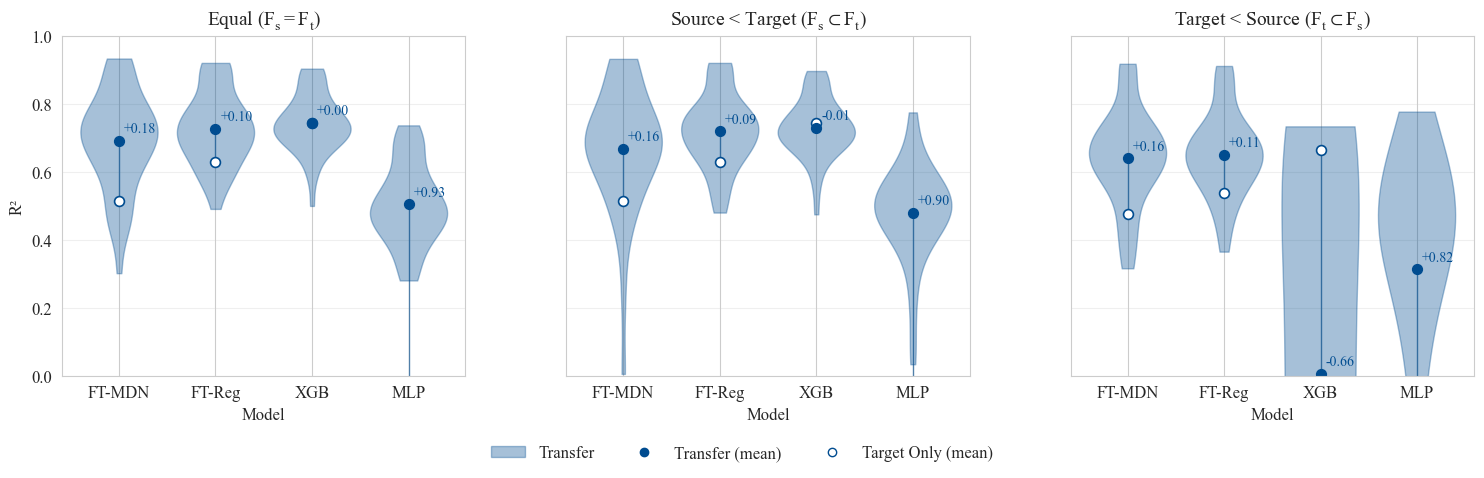

In [289]:
fig, axes = plot_hetero_transfer_highlight(
    raw_all,
    panel_size=5,
    y_range=(0,1),
    transfer_style='violin',      # default
    single_color="#004c90",
    summary='mean',             # consistent stat for both dots
    show_delta=True,              # optional ΔR² labels
    models_order=['FT-MDN','FT-Reg','XGB','MLP'],
    save_path=FIG_DIR / "hetero_transfer_violin_highlight.pdf"
)


## Transfer by Target Size

📄 saved: sim_runs_20250817_130825/figures/transfer_vs_target_size_by_hetero.pdf


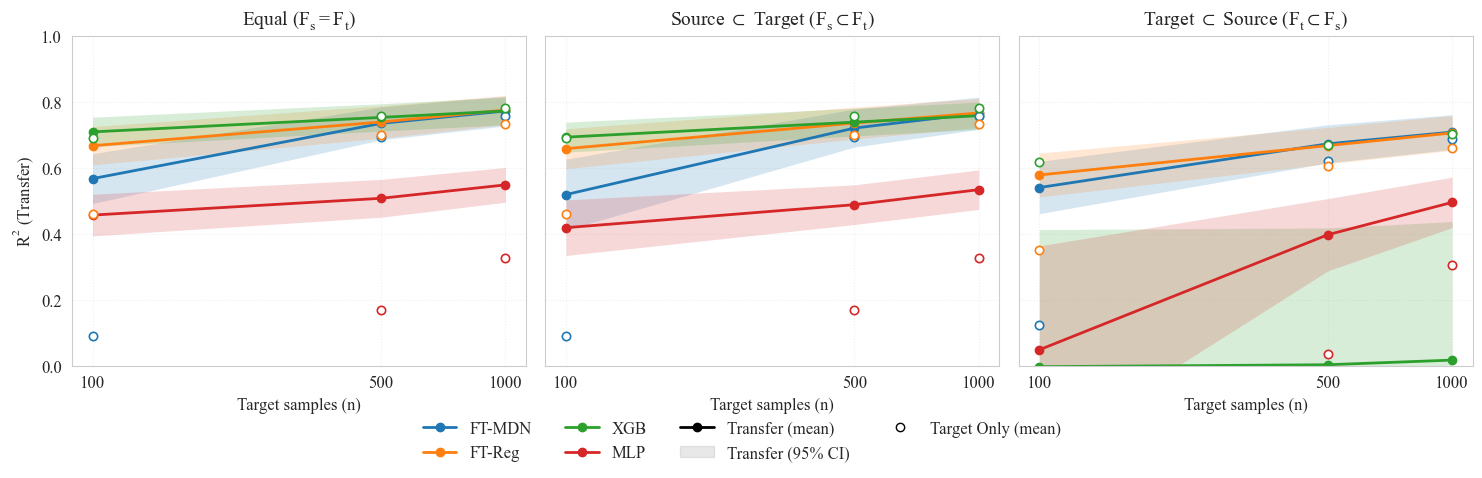

In [310]:
fig, axes = plot_transfer_absolute_by_target_size(
    raw_all,
    models_order=['FT-MDN','FT-Reg','XGB','MLP'],
    panel_size=5,
    x_scale="log",
    y_range=(0,1),
    save_path=FIG_DIR / "transfer_vs_target_size_by_hetero.pdf"
)


## Heatmap

In [428]:

# ---------- utilities ----------

def _paper_rc(font="Times New Roman"):
    plt.rcParams.update({
        "font.family": font,
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 12,
        "mathtext.fontset": "stix",
        "mathtext.default": "regular"
    })

def _titles_math():
    # include “Shift” in column headers
    return {
        'equal': r'Equal ($F_s = F_t$)',
        'source_subset': r'Source $\subset$ Target ($F_s \subset F_t$)',
        'target_subset': r'Target $\subset$ Source ($F_t \subset F_s$)',
        'covariate': 'Covariate Shift',
        'conditional': 'Concept Shift',
        'label': 'Label Shift'
    }

def _require_cols(df, cols):
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise ValueError(f"Missing required columns: {miss}")

def _rowwise_shift_score(df):
    score = pd.Series(np.nan, index=df.index, dtype=float)
    if 'combined_shift_score' in df.columns:
        s = pd.to_numeric(df['combined_shift_score'], errors='coerce')
        score = score.mask(s.notna(), s)
    if 'feature_shift_score' in df.columns:
        s = pd.to_numeric(df['feature_shift_score'], errors='coerce')
        m = df['shift_type'].isin(['covariate','conditional']) & score.isna()
        score.loc[m] = s.loc[m]
    if 'label_shift_score' in df.columns:
        s = pd.to_numeric(df['label_shift_score'], errors='coerce')
        m = df['shift_type'].eq('label') & score.isna()
        score.loc[m] = s.loc[m]
    return df.assign(score_for_bin=score)

def _bin_shift_quantiles_codes(df, n_bins=6):
    out = []
    for st, sub in df.groupby('shift_type', dropna=False):
        s = pd.to_numeric(sub['score_for_bin'], errors='coerce')
        finite = s.notna()
        sub_out = sub.copy()
        if finite.any():
            try:
                q = pd.qcut(s[finite], q=n_bins, duplicates='drop')
            except Exception:
                ranks = s[finite].rank(method='first')
                q = pd.qcut(ranks, q=n_bins, duplicates='drop')
            sub_out.loc[finite, 'shift_bin_idx'] = q.cat.codes.astype(float)
        else:
            sub_out['shift_bin_idx'] = np.nan
        out.append(sub_out)
    return pd.concat(out, axis=0)

def _interp_fill_dataframe(mat_df, iters_linear=2, iters_neighbor=1):
    A = mat_df.copy().astype(float)
    for _ in range(max(0, iters_linear)):
        A = A.interpolate(axis=1, limit_direction='both')
        A = A.interpolate(axis=0, limit_direction='both')
    for _ in range(max(0, iters_neighbor)):
        arr = A.to_numpy()
        mask = ~np.isfinite(arr)
        if not mask.any():
            break
        up    = np.roll(arr,  1, axis=0); up[0,:]    = np.nan
        down  = np.roll(arr, -1, axis=0); down[-1,:] = np.nan
        left  = np.roll(arr,  1, axis=1); left[:,0]  = np.nan
        right = np.roll(arr, -1, axis=1); right[:,-1]= np.nan
        neigh = np.nanmean(np.stack([up,down,left,right], axis=0), axis=0)
        arr[mask] = neigh[mask]
        A = pd.DataFrame(arr, index=A.index, columns=A.columns)
    return A

def _cmap_with_bad(cmap='viridis', bad='lightgray'):
    base = mpl.cm.get_cmap(cmap) if isinstance(cmap, str) else cmap
    if hasattr(base, 'with_extremes'):
        return base.with_extremes(bad=bad)
    if hasattr(base, 'copy'):
        cp = base.copy(); cp.set_bad(bad); return cp
    colors = base(np.linspace(0, 1, 256))
    cp = mpl.colors.ListedColormap(colors); cp.set_bad(bad); return cp

# ---------- main plot (FT-MDN only) ----------

def plot_ft_mdn_heatmap(
    df,
    hetero_order=('equal','source_subset','target_subset'),
    shift_types=('covariate','conditional','label'),
    n_shift_bins=6,
    panel_size=4.2,
    cmap='viridis',
    vmin=0.0, vmax=1.0,
    smooth_linear_iters=2,
    smooth_neighbor_iters=1,
    show_counts=False,
    count_fontsize=8,
    # overarching headers
    add_overarching_headers=True,
    col_header_pad=0.015,   # above top axes (figure fraction)
    row_header_pad=0.035,   # farther left so it won’t overflow
    row_header_rotation=90,
    # figure margins (figure fractions) — we control spacing explicitly
    left_margin=0.12, right_margin=0.98, top_margin=0.90, bottom_margin=0.12,
    # main title position
    suptitle_y=0.785,
    # bottom colorbar controls
    bottom_cbar=True,
    cbar_width_frac=0.66,   # 2/3 width, centered
    cbar_height=0.02,       # height in figure fraction
    cbar_in_margin=True,    # place colorbar within the reserved bottom margin
    save_path=None
):
    """
    FT-MDN ONLY. Rows = heterogeneity, Cols = shift type.
    x = target_n ; y = shift intensity quantile (Q1…Qk) ; color = mean R²(Transfer).

    Improvements:
      • Manual margins (no constrained_layout), so we can push the grid up
        and put a bottom colorbar much lower.
      • Column headers: “Covariate/Concept/Label Shift” above columns.
      • Row headers left, pushed extra left via row_header_pad.
      • Bottom horizontal colorbar centered at 2/3 width, clearly separated.
    """
    _require_cols(df, ['hetero','shift_type','target_n','model_name','r2_transfer_learning'])
    _paper_rc()
    T = _titles_math()

    # filter FT-MDN
    d = df[df['model_name'].astype(str).str.strip().str.lower() == 'ft-mdn'].copy()
    if d.empty:
        raise ValueError("No rows found for model_name == 'FT-MDN'.")
    d = d.dropna(subset=['hetero','shift_type','target_n','r2_transfer_learning'])
    d = d[d['shift_type'].isin(shift_types)]
    d['hetero'] = pd.Categorical(d['hetero'], categories=list(hetero_order), ordered=True)
    d['shift_type'] = pd.Categorical(d['shift_type'], categories=list(shift_types), ordered=True)

    # robust shift score + binning
    d = _rowwise_shift_score(d)
    d = _bin_shift_quantiles_codes(d, n_bins=n_shift_bins)

    # global axes
    xs_global = sorted(pd.unique(d['target_n']))
    max_code = int(np.nanmax(d['shift_bin_idx'])) if np.isfinite(d['shift_bin_idx']).any() else n_shift_bins-1
    ys_global = list(range(max_code + 1))
    if len(xs_global) == 0:
        raise ValueError("No target_n values for FT-MDN after filtering.")

    # figure (no constrained_layout)
    n_rows, n_cols = len(hetero_order), len(shift_types)
    fig_w, fig_h = n_cols * panel_size, n_rows * panel_size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    # manual spacing so we have real estate for the bottom colorbar
    fig.subplots_adjust(left=left_margin, right=right_margin, top=top_margin, bottom=bottom_margin)

    if n_rows == 1 and n_cols == 1:   axes = np.array([[axes]])
    elif n_rows == 1:                 axes = axes.reshape(1, -1)
    elif n_cols == 1:                 axes = axes.reshape(-1, 1)

    cmap_obj = _cmap_with_bad(cmap, bad='lightgray')
    im_last = None

    for r, het in enumerate(hetero_order):
        for c, st in enumerate(shift_types):
            ax = axes[r, c]
            sub_raw = d[(d['hetero']==het) & (d['shift_type']==st)].copy()

            if sub_raw.empty:
                mat = np.full((len(ys_global), len(xs_global)), np.nan)
                im = ax.imshow(np.ma.array(mat, mask=np.isnan(mat)), origin='lower', aspect='auto',
                               vmin=vmin, vmax=vmax, cmap=cmap_obj)
                im_last = im
            else:
                sub = sub_raw.dropna(subset=['shift_bin_idx'])
                xs = xs_global; ys = ys_global

                if sub.empty:
                    mat = np.full((len(ys_global), len(xs_global)), np.nan)
                    im = ax.imshow(np.ma.array(mat, mask=np.isnan(mat)), origin='lower', aspect='auto',
                                   vmin=vmin, vmax=vmax, cmap=cmap_obj)
                    im_last = im
                else:
                    grp = (sub.groupby(['shift_bin_idx','target_n'], as_index=False)
                               .agg(mean_r2=('r2_transfer_learning','mean'),
                                    count=('r2_transfer_learning','size')))
                    pivot_val = grp.pivot(index='shift_bin_idx', columns='target_n', values='mean_r2')
                    pivot_cnt = grp.pivot(index='shift_bin_idx', columns='target_n', values='count')
                    pivot_val = pivot_val.reindex(index=ys, columns=xs)
                    pivot_cnt = pivot_cnt.reindex(index=ys, columns=xs)

                    if np.isfinite(pivot_val.to_numpy()).any():
                        mat_filled = _interp_fill_dataframe(pivot_val,
                                                            iters_linear=smooth_linear_iters,
                                                            iters_neighbor=smooth_neighbor_iters)
                        if np.isnan(mat_filled.to_numpy()).any():
                            mat_filled = mat_filled.apply(lambda col: col.fillna(col.mean()), axis=0)
                            mat_filled = mat_filled.apply(lambda row: row.fillna(row.mean()), axis=1)
                            if np.isnan(mat_filled.to_numpy()).any():
                                gmean = np.nanmean(mat_filled.to_numpy())
                                if np.isfinite(gmean):
                                    mat_filled = mat_filled.fillna(gmean)
                    else:
                        mat_filled = pivot_val.copy()

                    arr = np.ma.array(mat_filled.to_numpy(), mask=~np.isfinite(mat_filled.to_numpy()))
                    im = ax.imshow(arr, origin='lower', aspect='auto',
                                   vmin=vmin, vmax=vmax, cmap=cmap_obj)
                    im_last = im

                    if show_counts and pivot_cnt.notna().values.any():
                        cnt = pivot_cnt.fillna(0).astype(int).to_numpy()
                        H, W = cnt.shape
                        for i in range(H):
                            for j in range(W):
                                ax.text(j, i, str(cnt[i, j]),
                                        ha='center', va='center',
                                        color=('white' if (np.isfinite(arr[i, j]) and arr[i, j] < (vmin+vmax)/2)
                                               else 'black'),
                                        fontsize=count_fontsize, alpha=0.7)

            # ticks & labels
            ax.set_xticks(np.arange(len(xs_global)))
            ax.set_xticklabels(xs_global)
            ax.set_yticks(np.arange(len(ys_global)))
            ax.set_yticklabels([f"Q{y+1}" for y in ys_global])
            if r == n_rows - 1: ax.set_xlabel('Target samples (n)')
            if c == 0:          ax.set_ylabel('Shift intensity (quantile)')
            for sp in ax.spines.values(): sp.set_visible(True)

    # --- overarching headers (top & left) ---
    if add_overarching_headers:
        Tm = _titles_math()
        fig.canvas.draw()
        # Column headers
        top_y = max(ax.get_position().y1 for ax in axes.ravel())
        for j, st in enumerate(shift_types):
            pos = axes[0, j].get_position()
            x_mid = (pos.x0 + pos.x1) / 2.0
            fig.text(x_mid, top_y + col_header_pad, Tm.get(st, st),
                     ha='center', va='bottom', fontsize=14)
        # Row headers (further left)
        left_x = min(ax.get_position().x0 for ax in axes.ravel())
        for i, het in enumerate(hetero_order):
            pos = axes[i, 0].get_position()
            y_mid = (pos.y0 + pos.y1) / 2.0
            fig.text(left_x - row_header_pad, y_mid, Tm.get(het, het),
                     ha='right', va='center', fontsize=14, rotation=row_header_rotation)

    # --- bottom horizontal colorbar, clearly separated ---
    if im_last is not None and bottom_cbar:
        fig.canvas.draw()
        # place the colorbar within the reserved bottom margin, centered
        x0 = (1.0 - cbar_width_frac) / 2.0
        # center vertically inside the bottom margin block
        y0 = (bottom_margin - cbar_height) / 2.0
        y0 = max(0.01, y0)  # keep on-canvas
        cax = fig.add_axes([x0, y0, cbar_width_frac, cbar_height])
        cbar = fig.colorbar(im_last, cax=cax, orientation='horizontal')
        cbar.set_label(r'$R^2$ (Transfer)')

    # main title
    fig.suptitle("FT-MDN — Transfer performance over target size × shift intensity", y=suptitle_y)

    if save_path is not None:
        try:
            savefig_pdf(save_path)
        except Exception:
            fig.savefig(save_path, bbox_inches='tight')

    return fig, axes


📄 saved: sim_runs_20250817_130825/figures/FTMDN_heatmap_headers.pdf


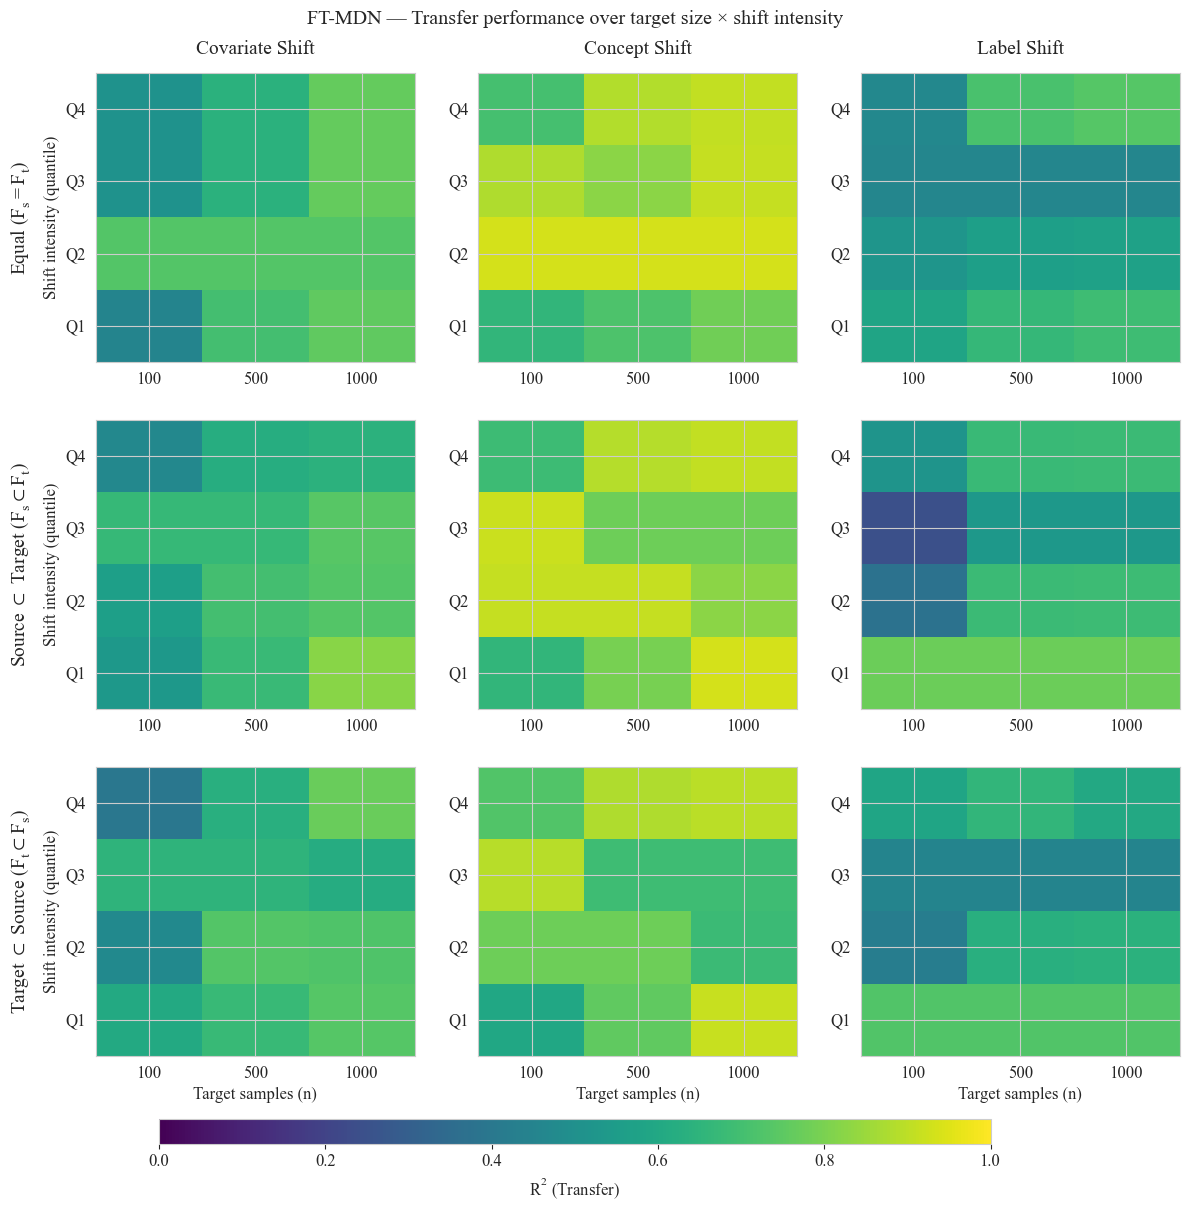

In [430]:
fig, axes = plot_ft_mdn_heatmap(
    raw_all,
    hetero_order=('equal','source_subset','target_subset'),
    shift_types=('covariate','conditional','label'),
    n_shift_bins=4,          # Q1…Q6; change to taste
    panel_size=4.2,
    cmap='viridis',
    vmin=0.0, vmax=1.0,
    smooth_linear_iters=2,
    smooth_neighbor_iters=1,
    add_overarching_headers=True,     # ← enables the top/left headers
    col_header_pad=0.012,
    row_header_pad=0.05,
    row_header_rotation=90,           # set to 0 for horizontal row labels
    suptitle_y=0.95,                  # pushes title a bit higher
    save_path=FIG_DIR / "FTMDN_heatmap_headers.pdf"
)


# More Analyses (NOT FINALISED)

In [74]:
import numpy as np
import pandas as pd

# 1) Ensure we have the required data
try:
    raw_all
except NameError:
    raw_all = load_all_raw()

req = {'hetero','model_name','target_n','r2_target_only','r2_transfer_learning'}
missing = req - set(raw_all.columns)
if missing:
    raise ValueError(f"Missing columns in raw_all: {missing}")

# 2) Long format with scenario label
long = (
    raw_all
    .melt(
        id_vars=['hetero','model_name','target_n'],
        value_vars=['r2_target_only','r2_transfer_learning'],
        var_name='scenario', value_name='r2'
    )
    .dropna(subset=['r2'])
)
long['scenario'] = long['scenario'].map({
    'r2_target_only': 'Target Only',
    'r2_transfer_learning': 'Transfer Learning'
})

# 3) Aggregate over runs (and over shift types) → mean, std, n, 95% CI
group_keys = ['hetero','target_n','model_name','scenario']
summ = (long
        .groupby(group_keys, as_index=False)
        .agg(mean_r2=('r2','mean'), sd=('r2','std'), n=('r2','size')))
summ['se'] = summ['sd'] / np.sqrt(summ['n'].clip(lower=1))
summ['ci95'] = 1.96 * summ['se'].fillna(0.0)

# 4) Pivot to get the two scenarios side-by-side
wide = (summ
        .pivot(index=['hetero','target_n','model_name'],
               columns='scenario',
               values=['mean_r2','sd','n'])
        )

# Make sure both scenarios exist as columns (fill if one is missing for a model)
for field in ['mean_r2','sd','n']:
    for scen in ['Target Only','Transfer Learning']:
        if (field, scen) not in wide.columns:
            wide[(field, scen)] = np.nan

# 5) Flatten and compute ΔR²
wide = wide.reindex(columns=[
    ('mean_r2','Target Only'),
    ('sd','Target Only'),
    ('n','Target Only'),
    ('mean_r2','Transfer Learning'),
    ('sd','Transfer Learning'),
    ('n','Transfer Learning'),
], fill_value=np.nan)

wide.columns = ['R2_TO_mean','R2_TO_sd','R2_TO_n','R2_TL_mean','R2_TL_sd','R2_TL_n']
wide['Delta_R2'] = wide['R2_TL_mean'] - wide['R2_TO_mean']

# 6) Order and prettify
hetero_order = ['equal','source_subset','target_subset']
wide = wide.reset_index()
wide['hetero'] = pd.Categorical(wide['hetero'], categories=hetero_order, ordered=True)
wide = wide.sort_values(['hetero','target_n','model_name']).reset_index(drop=True)

# Pretty columns: mean ± sd (and keep raw numeric columns too)
def fmt_mu_sd(mu, sd):
    if pd.isna(mu): return ""
    return f"{mu:.3f} ± {0 if pd.isna(sd) else sd:.3f}"

pretty = wide.copy()
pretty['R2 Target Only (mean ± sd)']      = [fmt_mu_sd(m, s) for m, s in zip(wide['R2_TO_mean'], wide['R2_TO_sd'])]
pretty['R2 Transfer (mean ± sd)']          = [fmt_mu_sd(m, s) for m, s in zip(wide['R2_TL_mean'], wide['R2_TL_sd'])]
pretty['ΔR² (TL − TO)']                    = pretty['Delta_R2'].map(lambda x: "" if pd.isna(x) else f"{x:+.3f}")

cols_order = [
    'hetero','target_n','model_name',
    'R2 Target Only (mean ± sd)','R2 Transfer (mean ± sd)','ΔR² (TL − TO)',
    # (optional) also keep numeric columns for downstream analysis:
    'R2_TO_mean','R2_TO_sd','R2_TO_n','R2_TL_mean','R2_TL_sd','R2_TL_n','Delta_R2'
]
comp_table = pretty[cols_order]

# 7) Save to CSV and LaTeX
from pathlib import Path
try:
    RES_DIR
except NameError:
    RES_DIR = Path("./results")  # fallback
RES_DIR.mkdir(parents=True, exist_ok=True)

csv_path = RES_DIR / "r2_comprehensive_table.csv"
tex_path = RES_DIR / "r2_comprehensive_table.tex"

comp_table.to_csv(csv_path, index=False)

# A LaTeX version with just the display columns
latex_cols = ['hetero','target_n','model_name',
              'R2 Target Only (mean ± sd)','R2 Transfer (mean ± sd)','ΔR² (TL − TO)']
with open(tex_path, "w") as f:
    f.write(comp_table[latex_cols].to_latex(index=False, escape=True))

print("✅ Saved:")
print("   CSV:", csv_path)
print("   LaTeX:", tex_path)

# 8) Show the first few rows (display columns)
display(comp_table[latex_cols].head(20))


✅ Saved:
   CSV: sim_runs_20250817_130825/results/r2_comprehensive_table.csv
   LaTeX: sim_runs_20250817_130825/results/r2_comprehensive_table.tex


/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/2510900712.py:105: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(comp_table[latex_cols].to_latex(index=False, escape=True))


,hetero,target_n,model_name,R2 Target Only (mean ± sd),R2 Transfer (mean ± sd),ΔR² (TL − TO)
0,equal,100,FT-MDN,0.090 ± 0.109,0.569 ± 0.149,+0.479
1,equal,100,FT-Reg,0.460 ± 0.212,0.668 ± 0.115,+0.208
2,equal,100,MLP,-1.768 ± 2.556,0.458 ± 0.125,+2.226
3,equal,100,XGB,0.692 ± 0.109,0.710 ± 0.088,+0.018
4,equal,500,FT-MDN,0.693 ± 0.107,0.736 ± 0.098,+0.043
5,equal,500,FT-Reg,0.702 ± 0.112,0.740 ± 0.097,+0.039
6,equal,500,MLP,0.171 ± 0.234,0.509 ± 0.113,+0.338
7,equal,500,XGB,0.757 ± 0.093,0.754 ± 0.082,-0.003
8,equal,1000,FT-MDN,0.759 ± 0.104,0.774 ± 0.090,+0.014
9,equal,1000,FT-Reg,0.733 ± 0.103,0.777 ± 0.087,+0.044


In [76]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- sanity checks ---
try:
    raw_all
except NameError:
    raw_all = load_all_raw()

# normalize column names if needed
if 'model_name' not in raw_all.columns and 'model_index' in raw_all.columns:
    raw_all = raw_all.rename(columns={'model_index': 'model_name'})

need = {'hetero','model_name','target_n','r2_target_only','r2_transfer_learning'}
missing = need - set(raw_all.columns)
if missing:
    raise ValueError(f"Missing columns in raw_all: {missing}")

# output dir
try:
    RES_DIR
except NameError:
    RES_DIR = Path("./results")
RES_DIR.mkdir(parents=True, exist_ok=True)

# formatting helpers
DEC = 3
fmt = lambda x: "" if pd.isna(x) else f"{x:.{DEC}f}"
fmt_delta = lambda x: "" if pd.isna(x) else f"{x:+.{DEC}f}"

# =========================================================
# A) PRIMARY TABLE: aggregated per heterogeneity scenario
#    (averaged over shift types & target sizes)
# =========================================================
aggA = (raw_all
        .groupby(['hetero','model_name'], as_index=False)
        .agg(R2_TargetOnly=('r2_target_only','mean'),
             R2_Transfer=('r2_transfer_learning','mean')))
aggA['Delta_R2'] = aggA['R2_Transfer'] - aggA['R2_TargetOnly']

# order by scenario, then by ΔR² (descending)
hetero_order = ['equal','source_subset','target_subset']
aggA['hetero'] = pd.Categorical(aggA['hetero'], categories=hetero_order, ordered=True)
aggA = aggA.sort_values(['hetero','Delta_R2'], ascending=[True, False])

# pretty display columns (no std)
prettyA = aggA[['hetero','model_name','R2_TargetOnly','R2_Transfer','Delta_R2']].copy()
prettyA.rename(columns={
    'hetero': 'Scenario',
    'model_name': 'Model',
    'R2_TargetOnly': 'R² Target Only',
    'R2_Transfer': 'R² Transfer',
    'Delta_R2': 'ΔR² (TL − TO)'
}, inplace=True)

prettyA['R² Target Only'] = prettyA['R² Target Only'].map(fmt)
prettyA['R² Transfer']    = prettyA['R² Transfer'].map(fmt)
prettyA['ΔR² (TL − TO)']  = prettyA['ΔR² (TL − TO)'].map(fmt_delta)

# save primary table
primary_csv = RES_DIR / "model_comparison_per_scenario.csv"
primary_tex = RES_DIR / "model_comparison_per_scenario.tex"
prettyA.to_csv(primary_csv, index=False)
with open(primary_tex, "w") as f:
    f.write(prettyA.to_latex(index=False, escape=True))
print("✅ Saved primary table:")
print("   CSV:", primary_csv)
print("   TeX:", primary_tex)

display(prettyA.head(20))

# =========================================================
# B) OPTIONAL: per-scenario tables by target size
#    (rows: model, columns: for each n — TO, TL, Δ)
# =========================================================
aggB = (raw_all
        .groupby(['hetero','target_n','model_name'], as_index=False)
        .agg(R2_TO=('r2_target_only','mean'),
             R2_TL=('r2_transfer_learning','mean')))
aggB['Delta_R2'] = aggB['R2_TL'] - aggB['R2_TO']

by_size_outputs = []
for scen in hetero_order:
    sub = aggB[aggB['hetero'] == scen].copy()
    if sub.empty:
        continue
    # make wide with columns like n50_TO, n50_TL, n50_Delta
    pieces = []
    for metric, newname in [('R2_TO','TO'), ('R2_TL','TL'), ('Delta_R2','Delta')]:
        piv = (sub
               .pivot(index='model_name', columns='target_n', values=metric)
               .sort_index(axis=1))
        # rename columns to compact labels
        piv.columns = [f"n{int(c)}_{newname}" for c in piv.columns]
        pieces.append(piv)
    wide = pd.concat(pieces, axis=1)
    # sort columns by n then metric order TO, TL, Delta
    def col_key(c):
        n = int(c.split('_')[0][1:])
        tag = c.split('_')[1]
        order = {'TO':0,'TL':1,'Delta':2}.get(tag, 3)
        return (n, order)
    wide = wide.reindex(sorted(wide.columns, key=col_key), axis=1)

    # pretty format (no std)
    wide_pretty = wide.copy()
    for c in wide_pretty.columns:
        if c.endswith('_Delta'):
            wide_pretty[c] = wide_pretty[c].map(fmt_delta)
        else:
            wide_pretty[c] = wide_pretty[c].map(fmt)

    wide_pretty = wide_pretty.reset_index().rename(columns={'model_name':'Model'})
    csv_path = RES_DIR / f"model_comparison_by_size_{scen}.csv"
    tex_path = RES_DIR / f"model_comparison_by_size_{scen}.tex"
    wide_pretty.to_csv(csv_path, index=False)
    with open(tex_path, "w") as f:
        f.write(wide_pretty.to_latex(index=False, escape=True))
    by_size_outputs.append((scen, csv_path, tex_path))

if by_size_outputs:
    print("\n📑 Optional per-size tables saved:")
    for scen, csv_path, tex_path in by_size_outputs:
        print(f"  - {scen}:")
        print(f"      CSV: {csv_path}")
        print(f"      TeX: {tex_path}")


✅ Saved primary table:
   CSV: sim_runs_20250817_130825/results/model_comparison_per_scenario.csv
   TeX: sim_runs_20250817_130825/results/model_comparison_per_scenario.tex


/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/2357393092.py:66: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(prettyA.to_latex(index=False, escape=True))


,Scenario,Model,R² Target Only,R² Transfer,ΔR² (TL − TO)
2,equal,MLP,-0.423,0.505,+0.928
0,equal,FT-MDN,0.514,0.693,+0.179
1,equal,FT-Reg,0.632,0.729,+0.097
3,equal,XGB,0.744,0.746,+0.002
6,source_subset,MLP,-0.423,0.481,+0.904
4,source_subset,FT-MDN,0.514,0.670,+0.156
5,source_subset,FT-Reg,0.632,0.721,+0.090
7,source_subset,XGB,0.744,0.731,-0.013
10,target_subset,MLP,-0.510,0.315,+0.824
8,target_subset,FT-MDN,0.478,0.642,+0.164



📑 Optional per-size tables saved:
  - equal:
      CSV: sim_runs_20250817_130825/results/model_comparison_by_size_equal.csv
      TeX: sim_runs_20250817_130825/results/model_comparison_by_size_equal.tex
  - source_subset:
      CSV: sim_runs_20250817_130825/results/model_comparison_by_size_source_subset.csv
      TeX: sim_runs_20250817_130825/results/model_comparison_by_size_source_subset.tex
  - target_subset:
      CSV: sim_runs_20250817_130825/results/model_comparison_by_size_target_subset.csv
      TeX: sim_runs_20250817_130825/results/model_comparison_by_size_target_subset.tex


/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/2357393092.py:119: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(wide_pretty.to_latex(index=False, escape=True))
/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/2357393092.py:119: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(wide_pretty.to_latex(index=False, escape=True))
/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/2357393092.py:119: FutureWarning: In futu

In [27]:
def plot_robustness(df, shift_col, title, scenario='transfer_learning',
                    K=8, ylim=(-0.2, 1.0), only_equal=True):
    ycol = f"r2_{scenario}"
    d = df[[shift_col, 'model_name', ycol, 'hetero', 'shift_type']].dropna()
    if only_equal:
        d = d[d['hetero'].eq('equal')]
    # quantile bins to stabilize ribbons
    d['bin'] = pd.qcut(d[shift_col], q=K, duplicates='drop')
    g = d.groupby(['model_name','bin'], as_index=False).agg(
        x=(shift_col, 'mean'), 
        y=(ycol, 'mean'),
        se=(ycol, lambda s: s.std(ddof=1)/np.sqrt(len(s)))
    )
    plt.figure(figsize=(7,4))
    for m in g['model_name'].unique():
        gm = g[g['model_name'].eq(m)].sort_values('x')
        if gm.empty: continue
        plt.plot(gm['x'], gm['y'], label=m)
        ci = 1.96*gm['se']
        plt.fill_between(gm['x'], gm['y']-ci, gm['y']+ci, alpha=0.2)
    plt.title(title); plt.xlabel(shift_col.replace('_',' ')); plt.ylabel('R²')
    plt.ylim(*ylim); plt.legend(title='Model'); plt.tight_layout(); plt.show()

def plot_transfer_gain(df, shift_col, K=8, ylim=(-0.2, 0.5), only_equal=True):
    cols = ['model_name', shift_col, 'r2_transfer_learning', 'r2_target_only', 'hetero']
    d = df[cols].dropna()
    if only_equal: d = d[d['hetero'].eq('equal')].copy()
    d['delta_r2'] = d['r2_transfer_learning'] - d['r2_target_only']
    d['bin'] = pd.qcut(d[shift_col], q=K, duplicates='drop')
    g = d.groupby(['model_name','bin'], as_index=False).agg(
        x=(shift_col,'mean'), y=('delta_r2','mean'),
        se=('delta_r2', lambda s: s.std(ddof=1)/np.sqrt(len(s))),
    )
    plt.figure(figsize=(7,4))
    for m in g['model_name'].unique():
        gm = g[g['model_name'].eq(m)].sort_values('x')
        if gm.empty: continue
        plt.plot(gm['x'], gm['y'], label=m)
        ci = 1.96*gm['se']; plt.fill_between(gm['x'], gm['y']-ci, gm['y']+ci, alpha=0.2)
    plt.axhline(0, ls='--', lw=1, color='k')
    plt.title(f'Transfer Gain vs {shift_col}')
    plt.xlabel(shift_col.replace('_',' ')); plt.ylabel('ΔR² (Transfer − Target)')
    plt.ylim(*ylim); plt.legend(); plt.tight_layout(); plt.show()


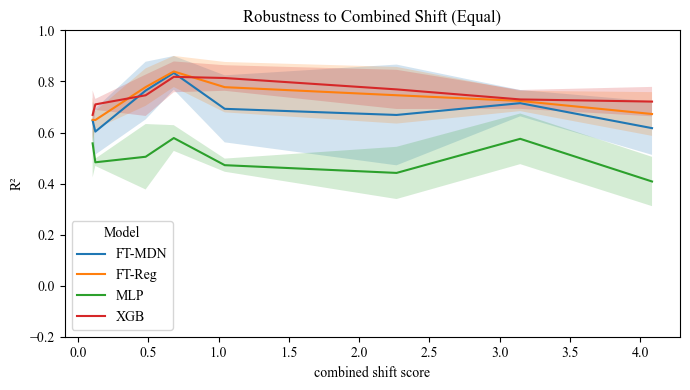

In [29]:
plot_robustness(all_raw, 'combined_shift_score', 'Robustness to Combined Shift (Equal)')


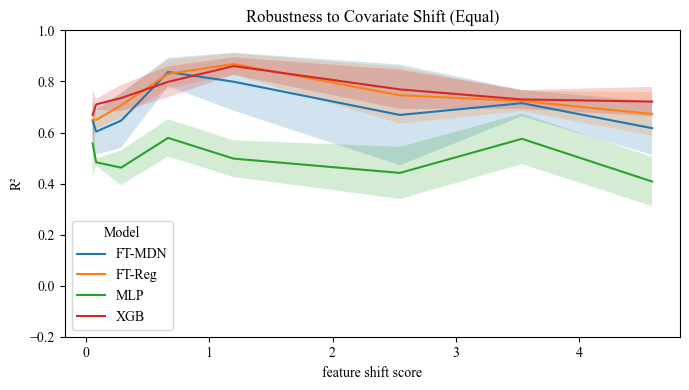

In [31]:
plot_robustness(all_raw, 'feature_shift_score', 'Robustness to Covariate Shift (Equal)')


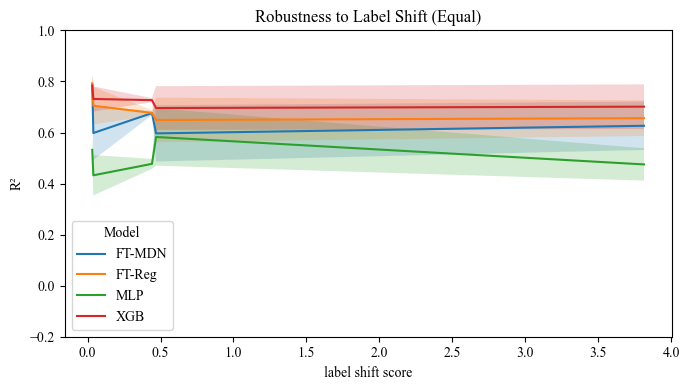

In [33]:
plot_robustness(all_raw, 'label_shift_score', 'Robustness to Label Shift (Equal)')


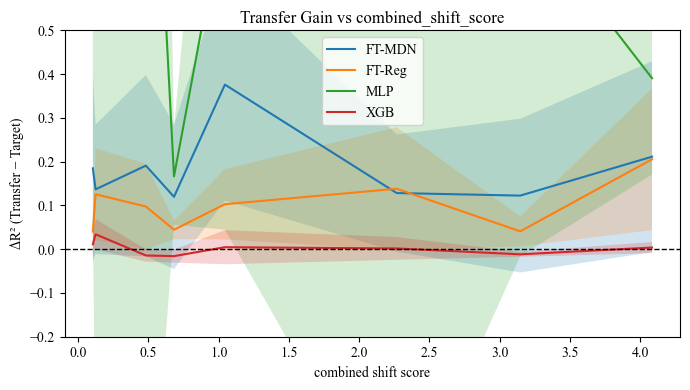

In [35]:
plot_transfer_gain(all_raw, 'combined_shift_score')


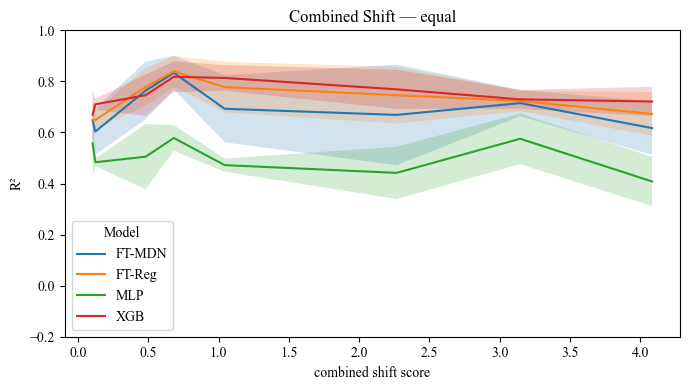

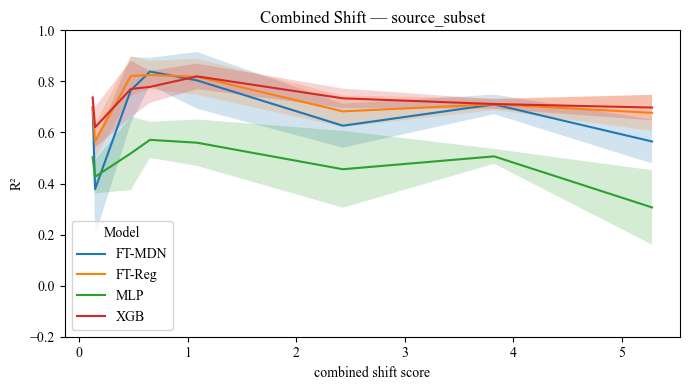

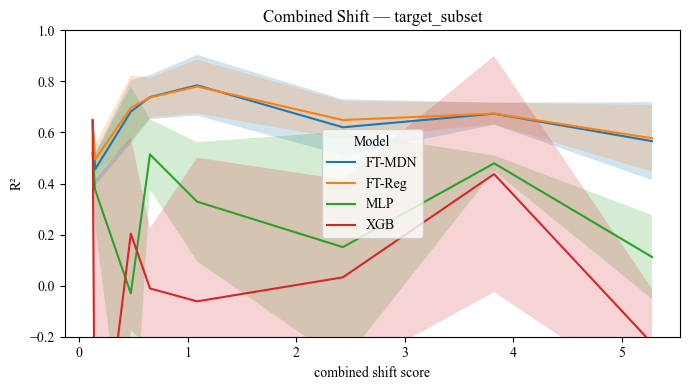

In [37]:
for hetero in ['equal','source_subset','target_subset']:
    sub = all_raw[all_raw['hetero'].eq(hetero)]
    if sub.empty: 
        continue
    plot_robustness(sub, 'combined_shift_score', f'Combined Shift — {hetero}', only_equal=False)


## C) R² (Transfer) vs TARGET SIZE / SHIFT TYPE / HETEROGENEITY

📄 saved: sim_runs_20250817_130825/figures/r2_transfer_vs_target_size.pdf


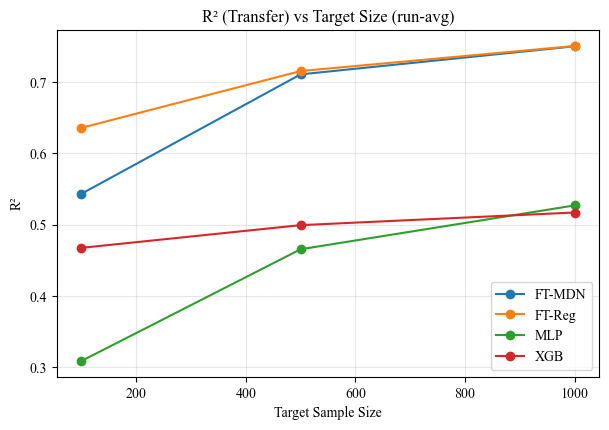

📄 saved: sim_runs_20250817_130825/figures/r2_transfer_by_shift_type.pdf


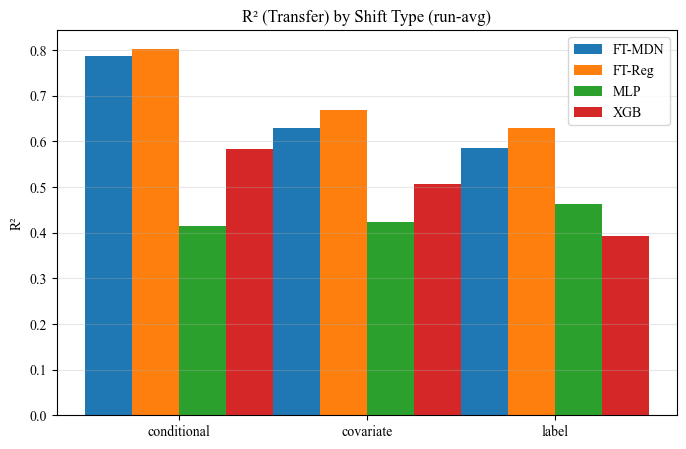

📄 saved: sim_runs_20250817_130825/figures/r2_transfer_by_heterogeneity.pdf


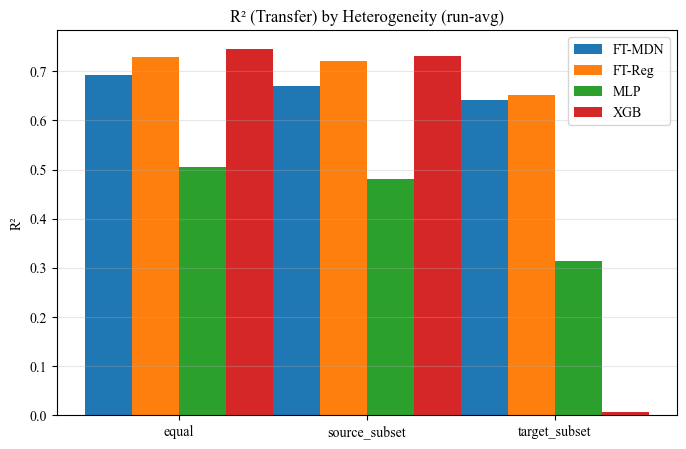

In [40]:
cell = (raw_all.groupby(['shift_type','hetero','target_n','model_name'])
               ['r2_transfer_learning'].mean().reset_index())

# (a) vs target size
plt.figure(figsize=(7, 4.5))
for name, sub in cell.groupby('model_name'):
    s = sub.groupby('target_n')['r2_transfer_learning'].mean().reset_index()
    plt.plot(s['target_n'], s['r2_transfer_learning'], marker='o', label=name)
plt.title('R² (Transfer) vs Target Size (run-avg)')
plt.xlabel('Target Sample Size'); plt.ylabel('R²')
plt.grid(True, alpha=0.3); plt.legend()
savefig_pdf(FIG_DIR / "r2_transfer_vs_target_size.pdf"); plt.show()

# (b) by shift type
plt.figure(figsize=(8, 5))
types = cell['shift_type'].unique().tolist()
x = np.arange(len(types)); width = 0.25
names = cell['model_name'].unique().tolist()
for i, name in enumerate(names):
    vals = [cell[(cell['model_name']==name) & (cell['shift_type']==t)]['r2_transfer_learning'].mean() for t in types]
    plt.bar(x + i*width, vals, width, label=name)
plt.xticks(x + width*(len(names)-1)/2, types)
plt.ylabel('R²'); plt.title('R² (Transfer) by Shift Type (run-avg)')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
savefig_pdf(FIG_DIR / "r2_transfer_by_shift_type.pdf"); plt.show()

# (c) by heterogeneity
plt.figure(figsize=(8, 5))
hets = cell['hetero'].unique().tolist()
x = np.arange(len(hets)); width = 0.25
for i, name in enumerate(names):
    vals = [cell[(cell['model_name']==name) & (cell['hetero']==h)]['r2_transfer_learning'].mean() for h in hets]
    plt.bar(x + i*width, vals, width, label=name)
plt.xticks(x + width*(len(names)-1)/2, hets)
plt.ylabel('R²'); plt.title('R² (Transfer) by Heterogeneity (run-avg)')
plt.legend(); plt.grid(True, axis='y', alpha=0.3)
savefig_pdf(FIG_DIR / "r2_transfer_by_heterogeneity.pdf"); plt.show()


## D) SIGNIFICANCE: FT variants vs XGB (paired within each run)

In [43]:
from scipy.stats import ttest_rel

def paired_within_run(index_csv=INDEX_CSV, metric_col='r2_transfer_learning'):
    idx = pd.read_csv(index_csv)
    out_rows = []
    for _, r in idx.iterrows():
        meta = r[['shift_type','hetero','target_n']].to_dict()
        df = pd.read_csv(OUT_ROOT / r['raw'])
        if 'model_name' not in df.columns and 'model_index' in df.columns:
            df.rename(columns={'model_index':'model_name'}, inplace=True)
        # pivot per simulation_id
        piv = df.pivot_table(index='simulation_id', columns='model_name', values=metric_col)
        # only keep sims where both models exist (paired)
        for model in ["FT-MDN", "FT-Reg"]:
            if model in piv.columns and "XGB" in piv.columns:
                sub = piv[[model, "XGB"]].dropna()
                if len(sub) >= 2:  # need pairs
                    t, p = ttest_rel(sub[model], sub["XGB"])
                    out_rows.append({
                        **meta, "model_vs":"%s vs XGB" % model,
                        "n_pairs": int(len(sub)),
                        "delta_mean": float((sub[model] - sub["XGB"]).mean()),
                        "delta_std": float((sub[model] - sub["XGB"]).std(ddof=1)) if len(sub)>1 else np.nan,
                        "tstat": float(t), "pval": float(p)
                    })
    return pd.DataFrame(out_rows)

cmp_df = paired_within_run()
if not cmp_df.empty:
    for m in ["FT-MDN", "FT-Reg"]:
        sub = cmp_df[cmp_df["model_vs"] == f"{m} vs XGB"]
        if not sub.empty:
            p_csv = RES_DIR / f"cmp_{m}_vs_XGB_r2_transfer.csv"
            p_tex = RES_DIR / f"cmp_{m}_vs_XGB_r2_transfer.tex"
            sub.to_csv(p_csv, index=False)
            with open(p_tex, "w") as f:
                f.write(sub.to_latex(index=False, float_format="%.3f"))
            print("🔬 saved:", p_csv)
    display(cmp_df.head())
else:
    print("No paired comparisons could be computed (check model presence in RAW files).")


🔬 saved: sim_runs_20250817_130825/results/cmp_FT-MDN_vs_XGB_r2_transfer.csv
🔬 saved: sim_runs_20250817_130825/results/cmp_FT-Reg_vs_XGB_r2_transfer.csv


/var/folders/x1/3zpk4hqd02v0nfh5qvn8565r0000gn/T/ipykernel_41060/1533118617.py:37: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(sub.to_latex(index=False, float_format="%.3f"))


,shift_type,hetero,target_n,model_vs,n_pairs,delta_mean,delta_std,tstat,pval
0,covariate,equal,100,FT-MDN vs XGB,5,-0.213192,0.121911,-3.910333,0.017389
1,covariate,equal,100,FT-Reg vs XGB,5,-0.078044,0.074549,-2.340870,0.079303
2,covariate,equal,500,FT-MDN vs XGB,5,-0.031956,0.064609,-1.105983,0.330773
3,covariate,equal,500,FT-Reg vs XGB,5,-0.017837,0.031801,-1.254197,0.278063
4,covariate,equal,1000,FT-MDN vs XGB,5,-0.003296,0.009157,-0.804787,0.466055


## E) HETEROSCEDASTICITY TEST of TL R² vs KL (using class helper)

In [46]:
hetero_df = None
try:
    # reuse class method by creating a tiny instance and assigning results_df
    tmp = MonteCarloSimulation(
        source_config=source_config,
        shift_param_ranges=shift_param_ranges,
        shift_type="all",
        num_simulations=1,
        model_class=[XGBoostModel],
        model_names=["XGB"],
        model_params=[dict(params=XGB_PARAMS)],
        scenarios=[["target_only"]],
        hetero_feature_mode="equal",
        drop_fraction=0.0,
        store_datasets=False,
        verbose=0,
        output_folder=str(OUT_ROOT),
    )
    tmp.results_df = raw_all.copy()
    hetero_df = tmp.test_heteroscedasticity_vs_shift(shift_col="combined_shift_score", p_val=0.05)
    print("Heteroscedasticity results:")
    display(hetero_df)
except Exception as e:
    print("heteroscedasticity test skipped:", e)


Heteroscedasticity results:


,model_name,LM stat,LM p-val,F stat,F p-val,heteroscedastic
0,MLP,0.491,0.4833,0.486,0.4870,False
1,XGB,1.383,0.2396,1.377,0.2428,False
2,FT-MDN,2.515,0.1128,2.525,0.1145,False
3,FT-Reg,4.360,0.0368,4.438,0.0370,True


## F) OVERLEAF BUNDLE (updated filenames)

In [ ]:
PAPER_DIR = OUT_ROOT / "paper_export"
PAPER_DIR.mkdir(parents=True, exist_ok=True)

# Tables
for name in ["agg_run_averaged.csv", "agg_run_averaged.tex"]:
    src = RES_DIR / name
    if src.exists():
        (PAPER_DIR / name).write_bytes(src.read_bytes())

for f in RES_DIR.glob("cmp_*_vs_XGB_r2_transfer.*"):
    (PAPER_DIR / f.name).write_bytes(f.read_bytes())

if hetero_df is not None:
    for f in RES_DIR.glob("heteroscedasticity_*.csv"):
        (PAPER_DIR / f.name).write_bytes(f.read_bytes())

# Figures
for f in FIG_DIR.glob("*.pdf"):
    (PAPER_DIR / f.name).write_bytes(f.read_bytes())

print("🧺 Overleaf bundle:", PAPER_DIR.resolve())
